# Análisis Exploratorio y Visualización — Ventas de Autos en PanamáAnálisis de un dataset simulado de ventas de autos en Panamá, enfocado en comparar marcas, ver cómo se mueven las ventas a lo largo del año y entender la composición por segmento de precio.El dataset es sintético (no son cifras reales del mercado panameño), así que lo que importa aquí es el proceso: limpieza, exploración y visualización con Python.Herramientas: pandas, NumPy, Matplotlib y Seaborn.

## 1. Configuración del entorno y carga de datos

In [1]:
# Importar librerías y configurar estilo visual
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
import seaborn as sns 
 
# Estilo visual global 
sns.set_theme(style='whitegrid', palette='muted') 
plt.rcParams['figure.dpi'] = 120       # resolución en pantalla 
plt.rcParams['figure.figsize'] = (10, 5) 
 
print('Matplotlib:', plt.matplotlib.__version__) 
print('Seaborn   :', sns.__version__)

Matplotlib: 3.10.6
Seaborn   : 0.13.2


In [2]:
# Cargar el dataset
df = pd.read_csv('ventas_autos_panama_2025_clean.csv', encoding='utf-8-sig') 
print('Dataset cargado correctamente.') 
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas') 
print(df.dtypes) 
df.head()

Dataset cargado correctamente.
Dimensiones: 225 filas x 11 columnas
anio              int64
mes               int64
marca            object
modelo           object
ventas            int64
nivel_ventas     object
trimestre        object
precio_usd      float64
ingreso_usd     float64
pct_mes         float64
segmento         object
dtype: object


,anio,mes,marca,modelo,ventas,nivel_ventas,trimestre,precio_usd,ingreso_usd,pct_mes,segmento
0,2025,11,Suzuki,Fronx,62,Baja,Q4 (Oct-Dic),20000.0,1240000.0,3.18,Medio
1,2025,7,Toyota,Hilux,295,Alta,Q3 (Jul-Sep),32000.0,9440000.0,12.85,Premium
2,2025,8,Toyota,RAV4,115,Alta,Q3 (Jul-Sep),36000.0,4140000.0,5.41,Lujo
3,2025,2,Kia,K3,51,Baja,Q1 (Ene-Mar),20000.0,1020000.0,3.46,Medio
4,2025,10,Hyundai,Venue,71,Baja,Q4 (Oct-Dic),18000.0,1278000.0,3.52,Medio


## 2. Ventas totales por marca y evolución mensual

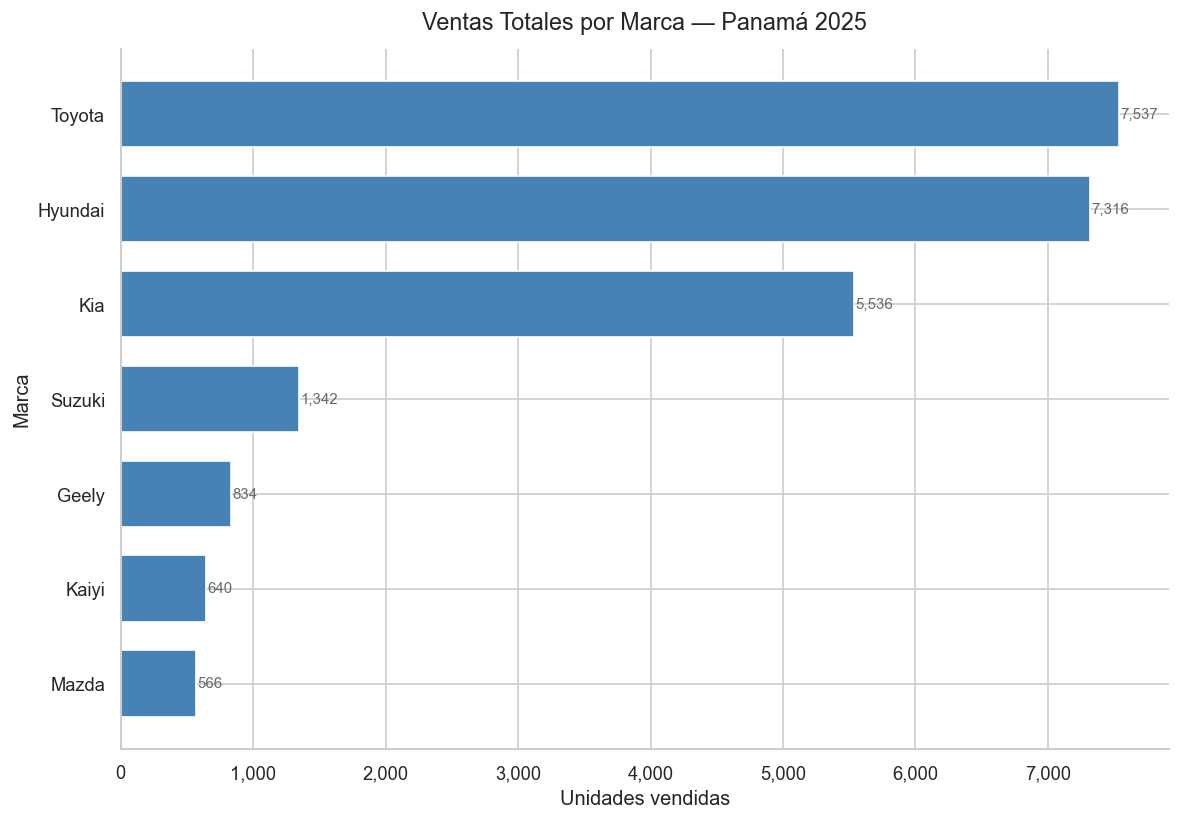

In [3]:
# Ventas totales por marca

ventas_marca = (df.groupby('marca')['ventas'].sum().sort_values(ascending=True))  
# ascending = True para barras horizontales 

 
fig, ax = plt.subplots(figsize=(10, 7)) 
bars = ax.barh(ventas_marca.index, ventas_marca.values, 
               color='steelblue', edgecolor='white', height=0.7) 
 
# Etiquetas de valor al final de cada barra 
for bar in bars: 
    ancho = bar.get_width() 
    ax.text(ancho + 10, bar.get_y() + bar.get_height() / 2, 
            f'{ancho:,}', va='center', fontsize=9, color='dimgray') 
 
ax.set_title('Ventas Totales por Marca — Panamá 2025', fontsize=14, pad=12) 
ax.set_xlabel('Unidades vendidas') 
ax.set_ylabel('Marca') 
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}')) 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_ventas_marca.png', dpi=150, bbox_inches='tight') 
plt.show() 

Toyota y Hyundai están prácticamente empatadas en el primer lugar, con Kia bastante cerca. Después de esas tres marcas hay una caída fuerte — el resto se reparte una porción mucho más chica del mercado.

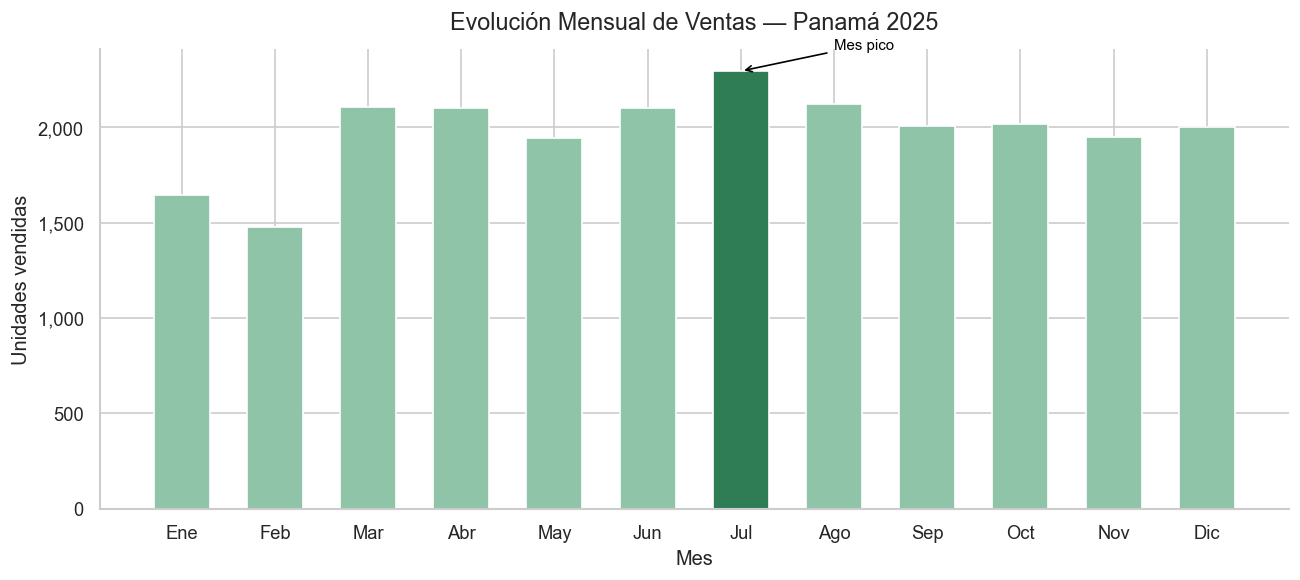

In [4]:
# Evolución mensual de ventas totales
meses_nombre = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun', 
                7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'} 
 
ventas_mes = df.groupby('mes')['ventas'].sum().reset_index() 
ventas_mes['nombre_mes'] = ventas_mes['mes'].map(meses_nombre) 
 
fig, ax = plt.subplots(figsize=(11, 5)) 
colores = ['#2E7D55' if v == ventas_mes['ventas'].max() 
           else '#90C4A8' for v in ventas_mes['ventas']] 
 
ax.bar(ventas_mes['nombre_mes'], ventas_mes['ventas'], 
       color=colores, edgecolor='white', width=0.6) 
ax.set_title('Evolución Mensual de Ventas — Panamá 2025', fontsize=14, pad=12) 
ax.set_xlabel('Mes') 
ax.set_ylabel('Unidades vendidas') 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}')) 
ax.spines[['top', 'right']].set_visible(False) 

# Anotación del mes pico 
idx_max = ventas_mes['ventas'].idxmax() 
ax.annotate('Mes pico', 
xy=(idx_max, ventas_mes['ventas'].iloc[idx_max]), 
xytext=(idx_max + 1, ventas_mes['ventas'].iloc[idx_max] * 1.05), 
arrowprops=dict(arrowstyle='->', color='black'), 
fontsize=9, color='black') 
plt.tight_layout() 
plt.savefig('graf_ventas_mes.png', dpi=150, bbox_inches='tight') 
plt.show() 

## 3. Tendencias mensuales por marca

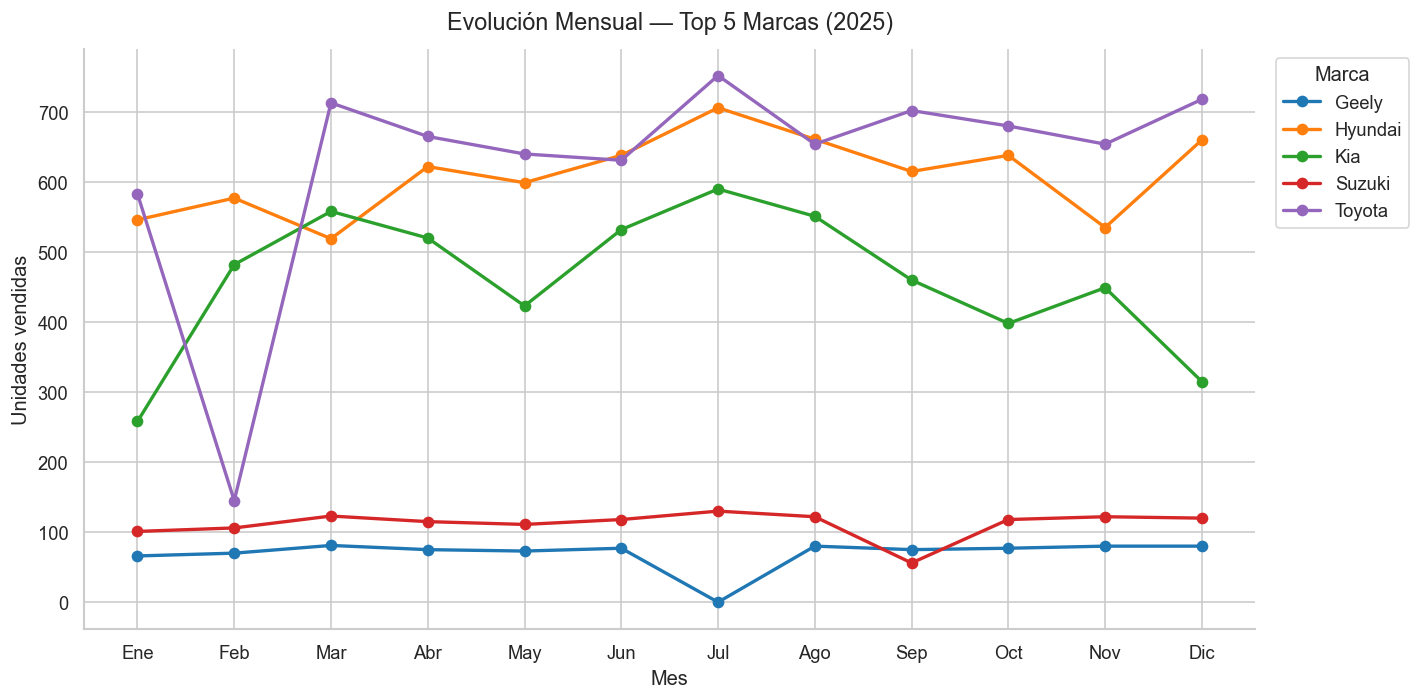

In [5]:
# Evolución mensual — Top 5 marcas
top5 = (df.groupby('marca')['ventas'] 
          .sum() 
          .sort_values(ascending=False) 
          .head(5) 
          .index.tolist()) 
 
df_top5 = df[df['marca'].isin(top5)] 
pivot_lineas = df_top5.pivot_table(values='ventas', index='mes', 
                                    columns='marca', aggfunc='sum', fill_value=0) 
 
fig, ax = plt.subplots(figsize=(12, 6)) 
palette = sns.color_palette('tab10', n_colors=5) 
 
for i, marca in enumerate(pivot_lineas.columns): 
    ax.plot(pivot_lineas.index, pivot_lineas[marca], 
            marker='o', linewidth=2, label=marca, color=palette[i]) 
 
ax.set_title('Evolución Mensual — Top 5 Marcas (2025)', fontsize=14, pad=12) 
ax.set_xlabel('Mes') 
ax.set_ylabel('Unidades vendidas') 
ax.set_xticks(range(1, 13)) 
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun', 
                    'Jul','Ago','Sep','Oct','Nov','Dic']) 
ax.legend(title='Marca', bbox_to_anchor=(1.01, 1), loc='upper left') 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}')) 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_lineas_top5.png', dpi=150, bbox_inches='tight') 
plt.show() 

Acá se ve algo interesante: no todas las marcas se mueven igual mes a mes. Hay unas más estables y otras con picos puntuales, casi todos cayendo cerca del mismo mes en que sube el total general.

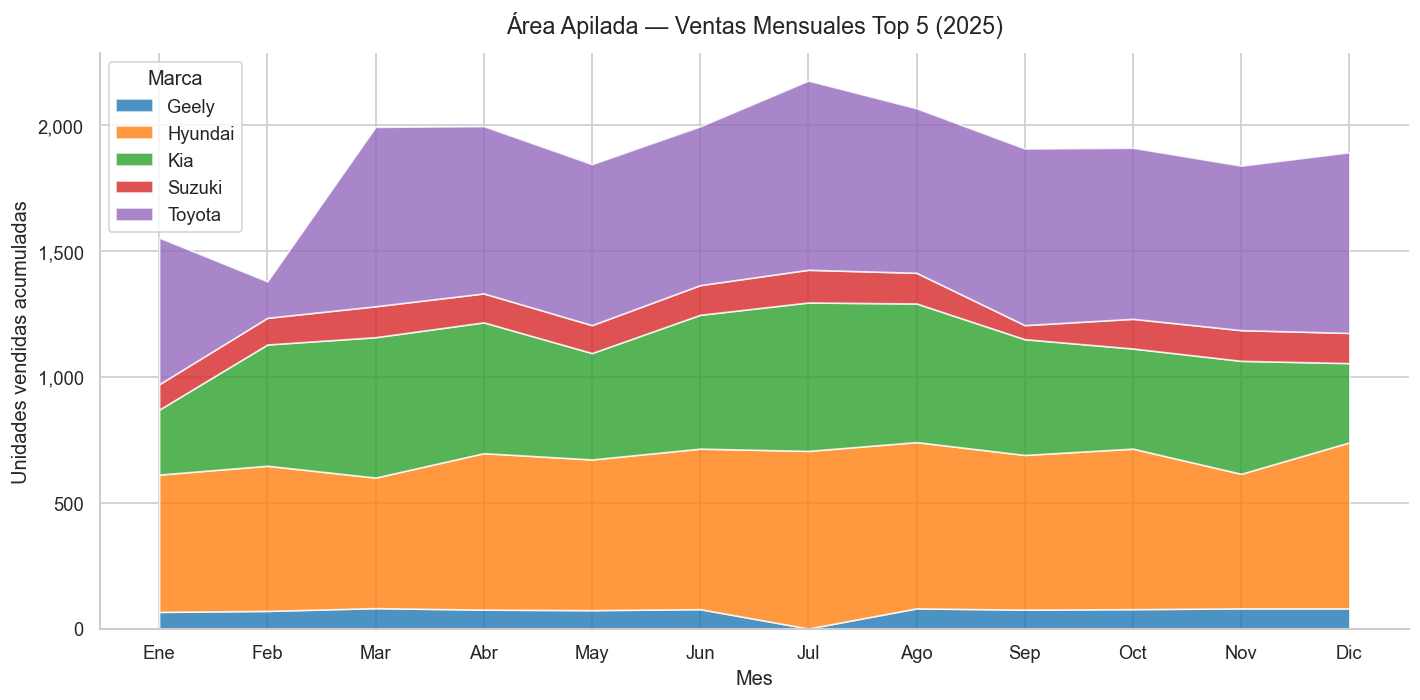

In [6]:
# Participación mensual del Top 5 (área apilada)
fig, ax = plt.subplots(figsize=(12, 6)) 
 
ax.stackplot(pivot_lineas.index, 
             [pivot_lineas[m] for m in pivot_lineas.columns], 
             labels=pivot_lineas.columns, 
colors=palette, alpha=0.8) 
ax.set_title('Área Apilada — Ventas Mensuales Top 5 (2025)', fontsize=14, pad=12) 
ax.set_xlabel('Mes') 
ax.set_ylabel('Unidades vendidas acumuladas') 
ax.set_xticks(range(1, 13)) 
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun', 
'Jul','Ago','Sep','Oct','Nov','Dic']) 
ax.legend(loc='upper left', title='Marca') 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}')) 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_area_apilada.png', dpi=150, bbox_inches='tight') 
plt.show() 

## 4. Participación de mercado

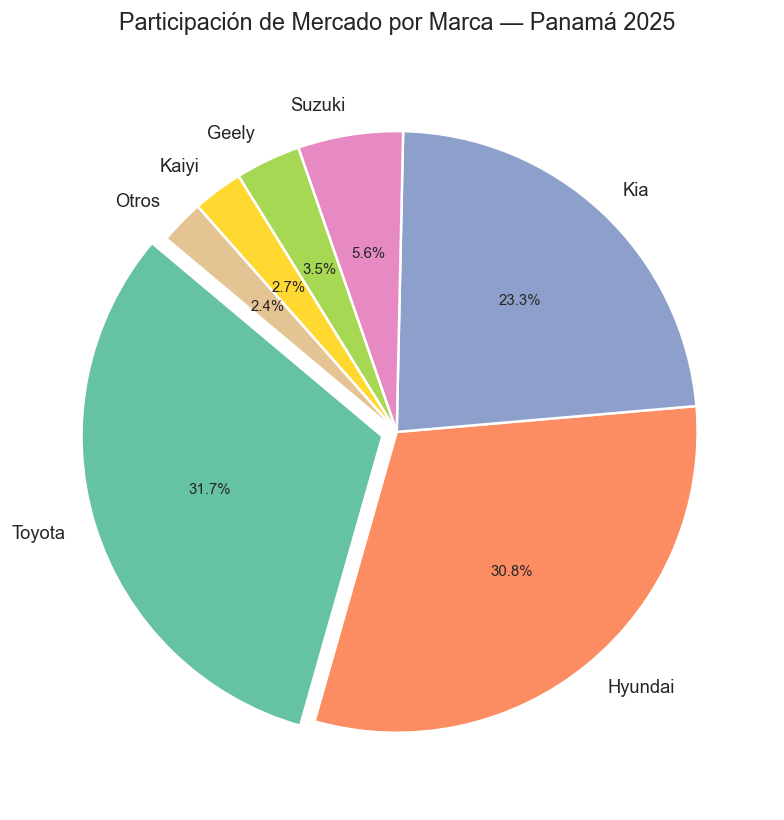

In [7]:
# Market share por marca
ventas_totales = df.groupby('marca') ['ventas'].sum().sort_values(ascending = False)

# Agrupar las marcas menores como 'Otros' 
top_n = 6 
top_marcas = ventas_totales.head(top_n) 
otros = ventas_totales.iloc[top_n:].sum() 
if otros > 0: 
    top_marcas['Otros'] = otros 
 
explode = [0.05] + [0] * (len(top_marcas) - 1)   # resaltar la primera 
 
fig, ax = plt.subplots(figsize=(9, 7)) 
wedges, texts, autotexts = ax.pie(top_marcas.values, 
    labels=top_marcas.index, 
    autopct='%1.1f%%', 
    explode=explode, 
    startangle=140, 
    colors=sns.color_palette('Set2', len(top_marcas)), 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} 
) 
for at in autotexts: 
    at.set_fontsize(9) 
ax.set_title('Participación de Mercado por Marca — Panamá 2025', 
             fontsize=14, pad=16) 
plt.tight_layout() 
plt.savefig('graf_pastel_mercado.png', dpi=150, bbox_inches='tight') 
plt.show() 

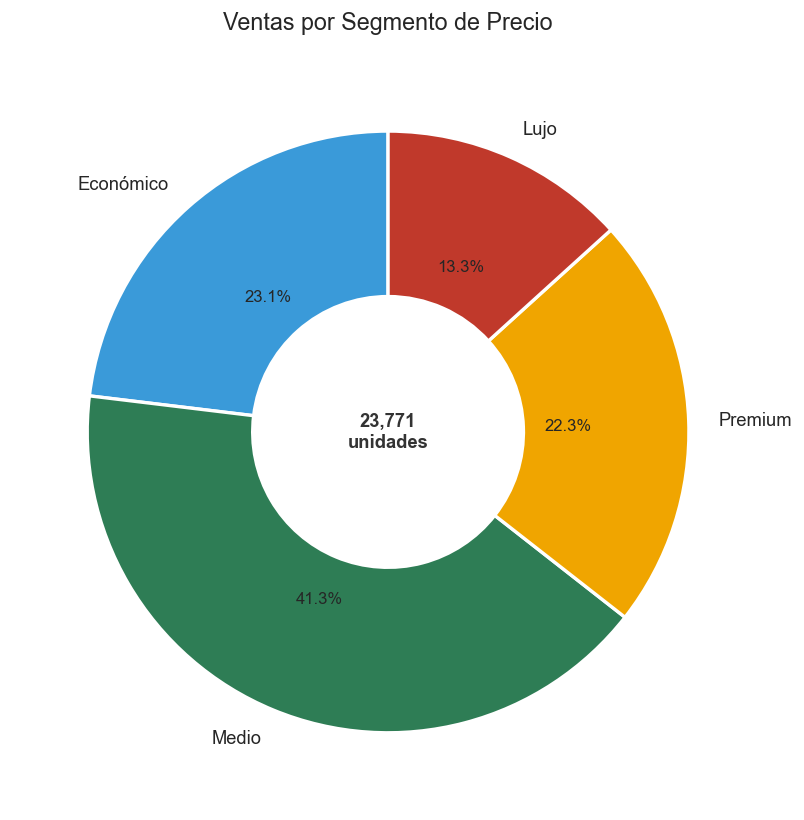

In [8]:
# Participación por segmento de precio
ventas_seg = df.groupby('segmento')['ventas'].sum() 
orden = ['Económico', 'Medio', 'Premium', 'Lujo'] 
ventas_seg = ventas_seg.reindex([s for s in orden if s in ventas_seg.index]) 
 
fig, ax = plt.subplots(figsize=(8, 7)) 
wedges, texts, autotexts = ax.pie( 
    ventas_seg.values, 
    labels=ventas_seg.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#3A9AD9','#2E7D55','#F0A500','#C0392B'], 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.55}  # dona 
) 
for at in autotexts: 
    at.set_fontsize(10)

ax.set_title('Ventas por Segmento de Precio', fontsize=14, pad=16) 

# Texto central de la dona 
total = ventas_seg.sum() 
ax.text(0, 0, f'{total:,}\nunidades', ha='center', va='center', 
fontsize=11, fontweight='bold', color='#333333') 
plt.tight_layout() 
plt.savefig('graf_dona_segmento.png', dpi=150, bbox_inches='tight') 
plt.show() 

## 5. Distribución de ventas por marca y segmento

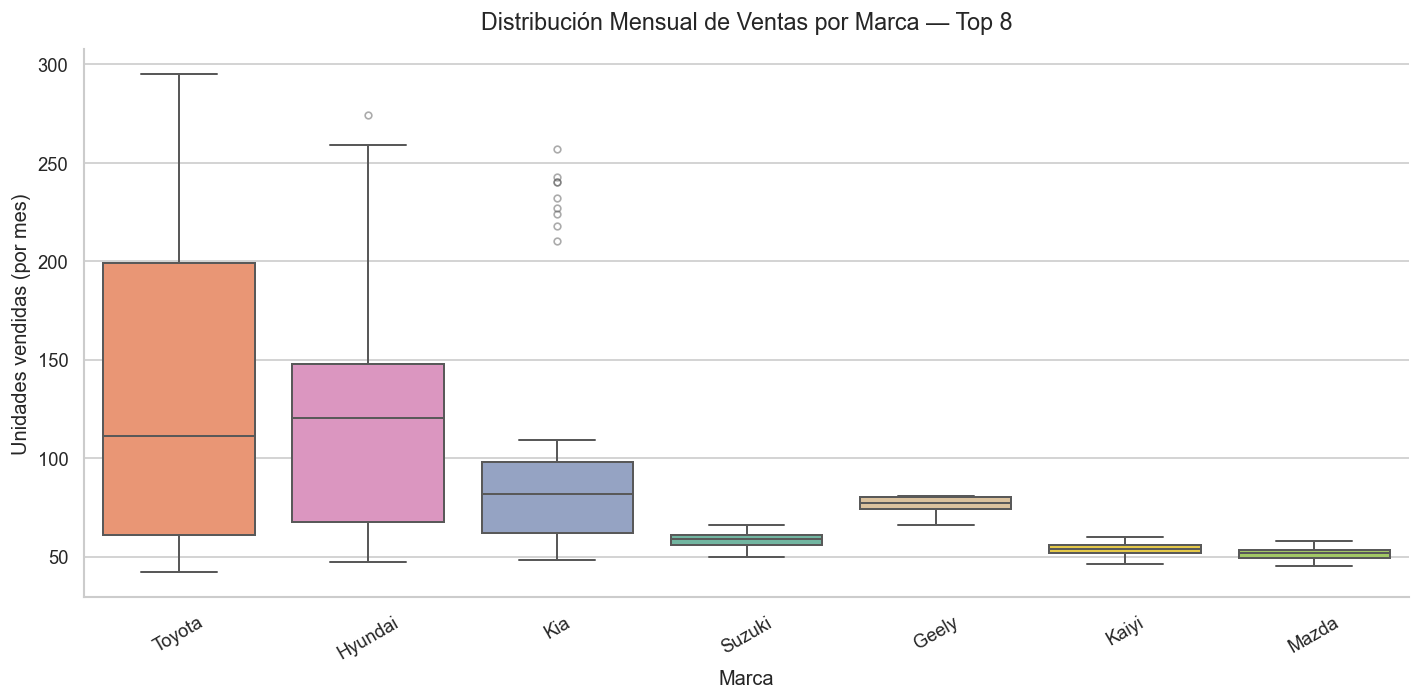

In [9]:
# Distribución de ventas por marca (boxplot)

# Filtrar Top 8 marcas para que el gráfico sea legible 
top8 = (df.groupby('marca')['ventas'].sum() 
          .sort_values(ascending=False) 
          .head(8).index.tolist()) 
df_top8 = df[df['marca'].isin(top8)] 
 
fig, ax = plt.subplots(figsize=(12, 6)) 
sns.boxplot(data=df_top8, x='marca', y='ventas', 
            order=top8,
            hue='marca',
            palette='Set2', linewidth=1.2, 
            flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5},
            legend=False,
            ax=ax) 
 
ax.set_title('Distribución Mensual de Ventas por Marca — Top 8', fontsize=14, 
pad=12) 
ax.set_xlabel('Marca') 
ax.set_ylabel('Unidades vendidas (por mes)') 
ax.tick_params(axis='x', rotation=30) 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_boxplot_marca.png', dpi=150, bbox_inches='tight') 
plt.show() 

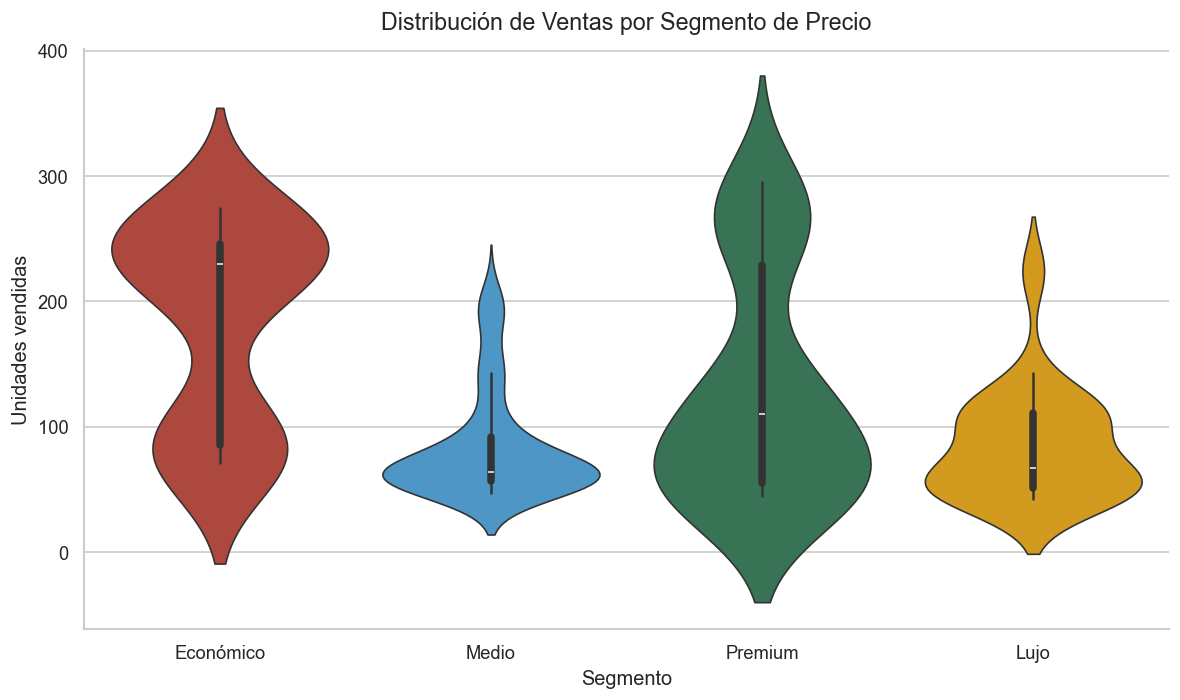

In [10]:
# Distribución de ventas por segmento de precio (violinplot)
orden_seg = ['Económico', 'Medio', 'Premium', 'Lujo'] 
df_seg = df[df['segmento'].isin(orden_seg)] 
 
fig, ax = plt.subplots(figsize=(10, 6)) 
sns.violinplot(data=df_seg, x='segmento', y='ventas', 
               order=orden_seg, 
               hue='segmento',   # ✔ requerido para usar palette
               palette=['#3A9AD9','#2E7D55','#F0A500','#C0392B'], 
               inner='box',          # muestra la caja dentro del violín 
               linewidth=1, 
               legend=False,     # ✔ evita leyenda redundante
               ax=ax) 
 
ax.set_title('Distribución de Ventas por Segmento de Precio', fontsize=14, pad=12) 
ax.set_xlabel('Segmento') 
ax.set_ylabel('Unidades vendidas') 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_violin_segmento.png', dpi=150, bbox_inches='tight') 
plt.show()

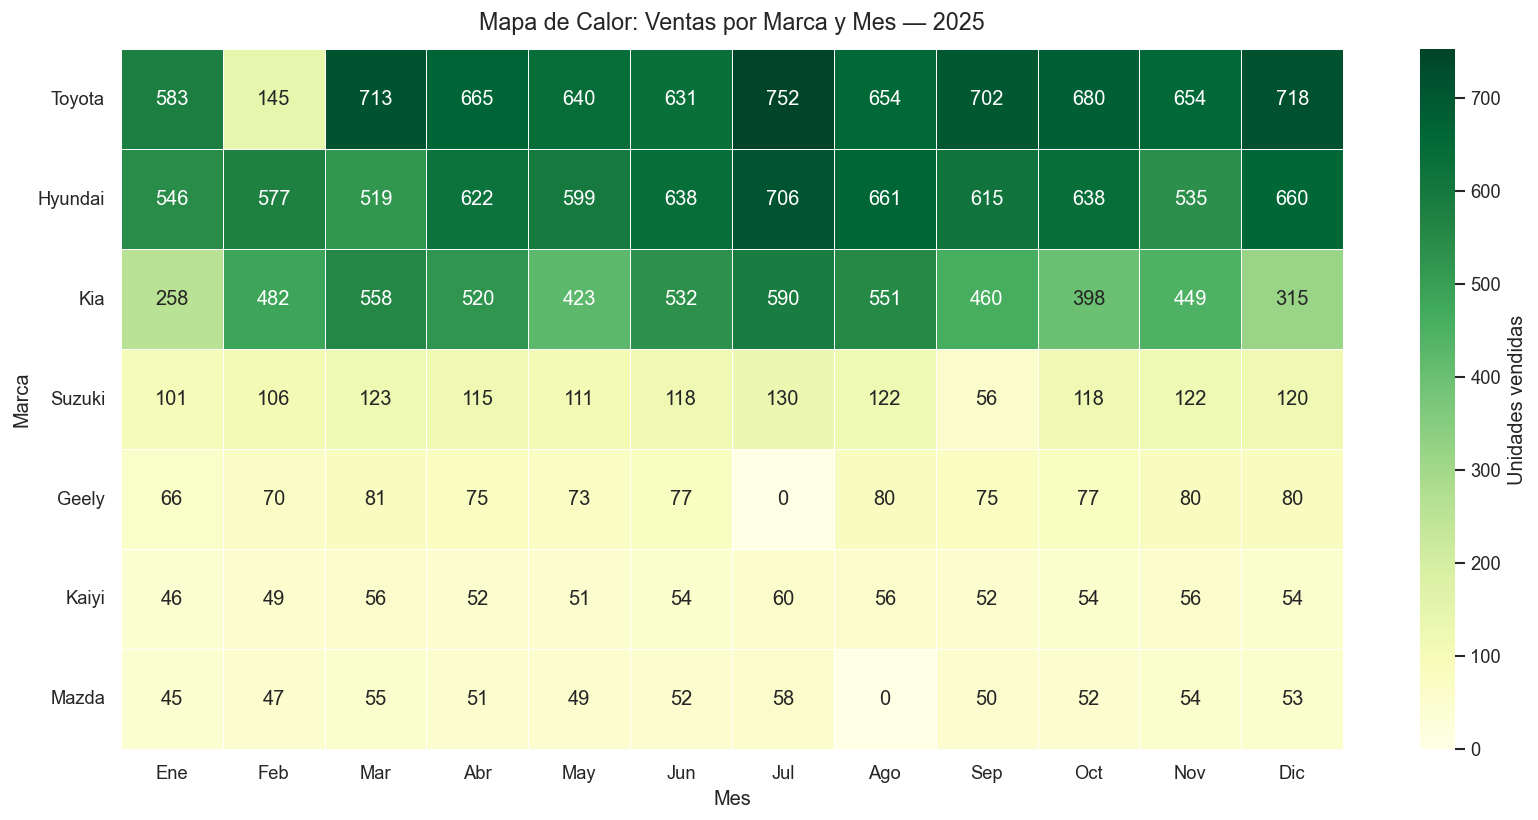

In [11]:
# Ventas por marca y mes (heatmap)
pivot_heat = df.pivot_table(values='ventas', index='marca', 
                             columns='mes', aggfunc='sum', fill_value=0) 
pivot_heat.columns = ['Ene','Feb','Mar','Abr','May','Jun', 
                      'Jul','Ago','Sep','Oct','Nov','Dic'] 
# Ordenar por total de ventas 
pivot_heat = pivot_heat.loc[pivot_heat.sum(axis=1).sort_values(ascending=False).index] 
 
fig, ax = plt.subplots(figsize=(14, 7)) 
sns.heatmap(pivot_heat, 
            annot=True, fmt='d',          # mostrar valores enteros 
            cmap='YlGn', 
            linewidths=0.4, linecolor='white', 
            cbar_kws={'label': 'Unidades vendidas'}, 
            ax=ax) 
 
ax.set_title('Mapa de Calor: Ventas por Marca y Mes — 2025', fontsize=14, pad=12) 
ax.set_xlabel('Mes') 
ax.set_ylabel('Marca') 
ax.tick_params(axis='y', rotation=0) 
plt.tight_layout() 
plt.savefig('graf_heatmap.png', dpi=150, bbox_inches='tight') 
plt.show() 

El segmento Premium es el que más se mueve de mes a mes; Económico en cambio se mantiene bastante parejo. En el heatmap se nota rápido cuáles combinaciones de marca y mes tienen los números más altos.

## 6. Distribución general y relación precio–ventas

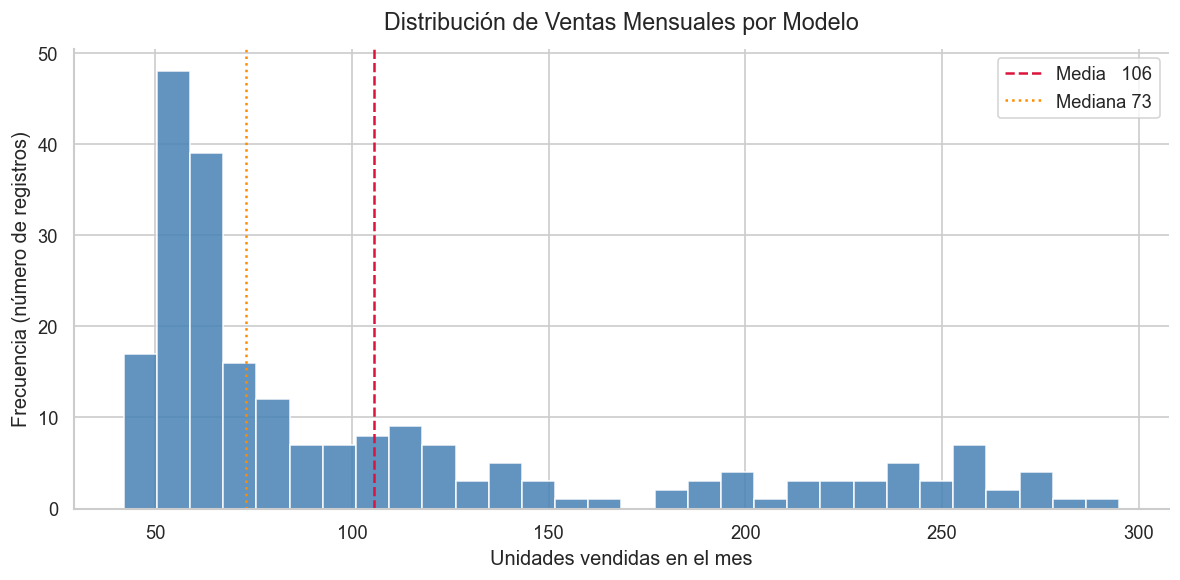

In [12]:
# Distribución de ventas mensuales por modelo
fig, ax = plt.subplots(figsize=(10, 5)) 
ax.hist(df['ventas'], bins=30, color='steelblue', edgecolor='white', alpha=0.85) 
 
# Líneas de referencia: media y mediana 
media  = df['ventas'].mean() 
mediana = df['ventas'].median() 
ax.axvline(media,   color='crimson',     linestyle='--', linewidth=1.5, 
label=f'Media   {media:.0f}') 
ax.axvline(mediana, color='darkorange',  linestyle=':',  linewidth=1.5, 
label=f'Mediana {mediana:.0f}') 
 
ax.set_title('Distribución de Ventas Mensuales por Modelo', fontsize=14, pad=12) 
ax.set_xlabel('Unidades vendidas en el mes') 
ax.set_ylabel('Frecuencia (número de registros)') 
ax.legend() 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_histograma.png', dpi=150, bbox_inches='tight') 
plt.show()

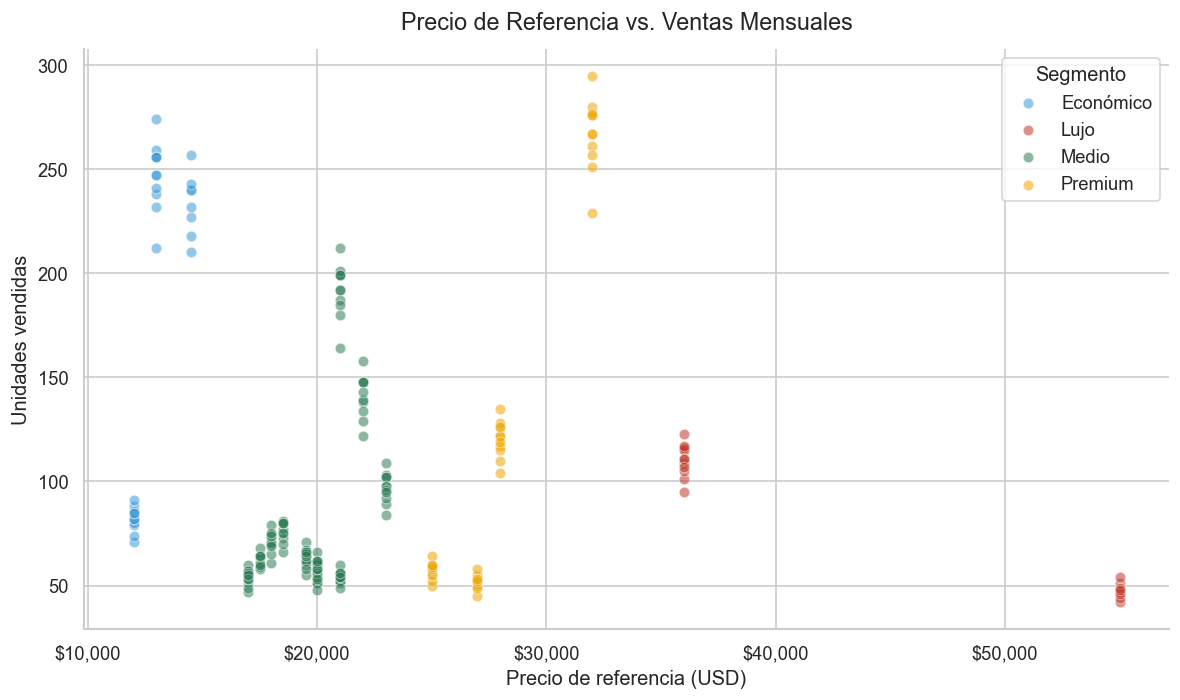

In [13]:
# Relación entre precio de referencia y ventas

fig, ax = plt.subplots(figsize=(10, 6)) 
 
# Un color por segmento 
colores_seg = {'Económico':'#3A9AD9','Medio':'#2E7D55', 
               'Premium':'#F0A500','Lujo':'#C0392B'} 
 
for seg, grp in df.groupby('segmento'): 
    ax.scatter(grp['precio_usd'], grp['ventas'], 
               label=seg, color=colores_seg.get(seg, 'gray'), 
               alpha=0.55, edgecolors='white', linewidths=0.5, s=40) 
 
ax.set_title('Precio de Referencia vs. Ventas Mensuales', fontsize=14, pad=12) 
ax.set_xlabel('Precio de referencia (USD)') 
ax.set_ylabel('Unidades vendidas') 
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}')) 
ax.legend(title='Segmento') 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_dispersion.png', dpi=150, bbox_inches='tight') 
plt.show() 

Los puntos del gráfico de dispersión están bastante repartidos, sin un patrón claro entre precio y unidades vendidas dentro de cada segmento. Las diferencias en ventas parecen depender más de la marca y el posicionamiento que del precio en sí.

## 7. Composición trimestral por segmento

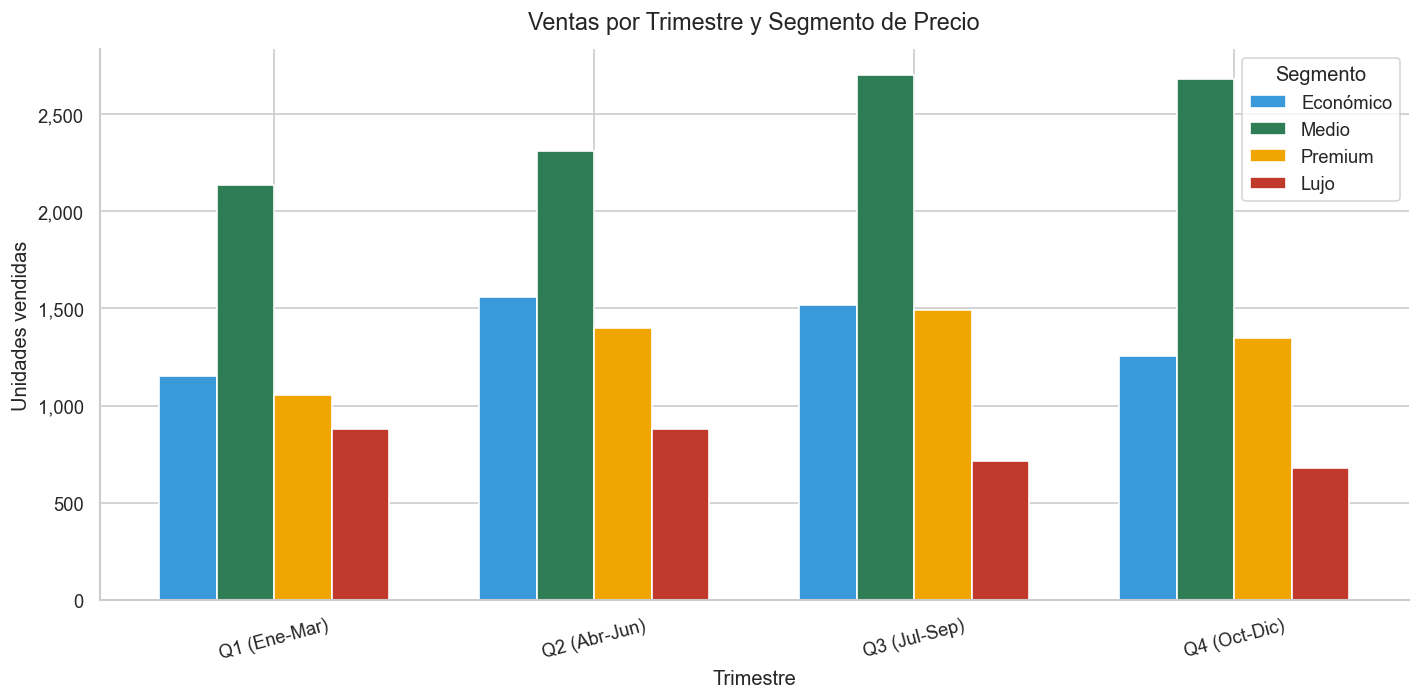

In [14]:
# Ventas por trimestre y segmento
import numpy as np 
 
orden_trim = ['Q1 (Ene-Mar)','Q2 (Abr-Jun)','Q3 (Jul-Sep)','Q4 (Oct-Dic)'] 
orden_seg  = ['Económico','Medio','Premium','Lujo'] 
 
pivot_trim = (df.groupby(['trimestre','segmento'])['ventas'] 
                .sum() 
                .unstack(fill_value=0) 
                .reindex(index=orden_trim, 
                         columns=[s for s in orden_seg if s in 
df['segmento'].unique()])) 
 
x      = np.arange(len(pivot_trim.index)) 
n_seg  = len(pivot_trim.columns) 
ancho  = 0.18 
colores_seg2 = ['#3A9AD9','#2E7D55','#F0A500','#C0392B'] 
 
fig, ax = plt.subplots(figsize=(12, 6)) 
for i, (seg, color) in enumerate(zip(pivot_trim.columns, colores_seg2)): 
    offset = (i - n_seg / 2 + 0.5) * ancho 
    bars = ax.bar(x + offset, pivot_trim[seg], ancho, 
                  label=seg, color=color, edgecolor='white') 
 
ax.set_title('Ventas por Trimestre y Segmento de Precio', fontsize=14, pad=12) 
ax.set_xlabel('Trimestre') 
ax.set_ylabel('Unidades vendidas') 
ax.set_xticks(x) 
ax.set_xticklabels(pivot_trim.index, rotation=15) 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}')) 
ax.legend(title='Segmento') 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_barras_agrupadas.png', dpi=150, bbox_inches='tight') 
plt.show() 

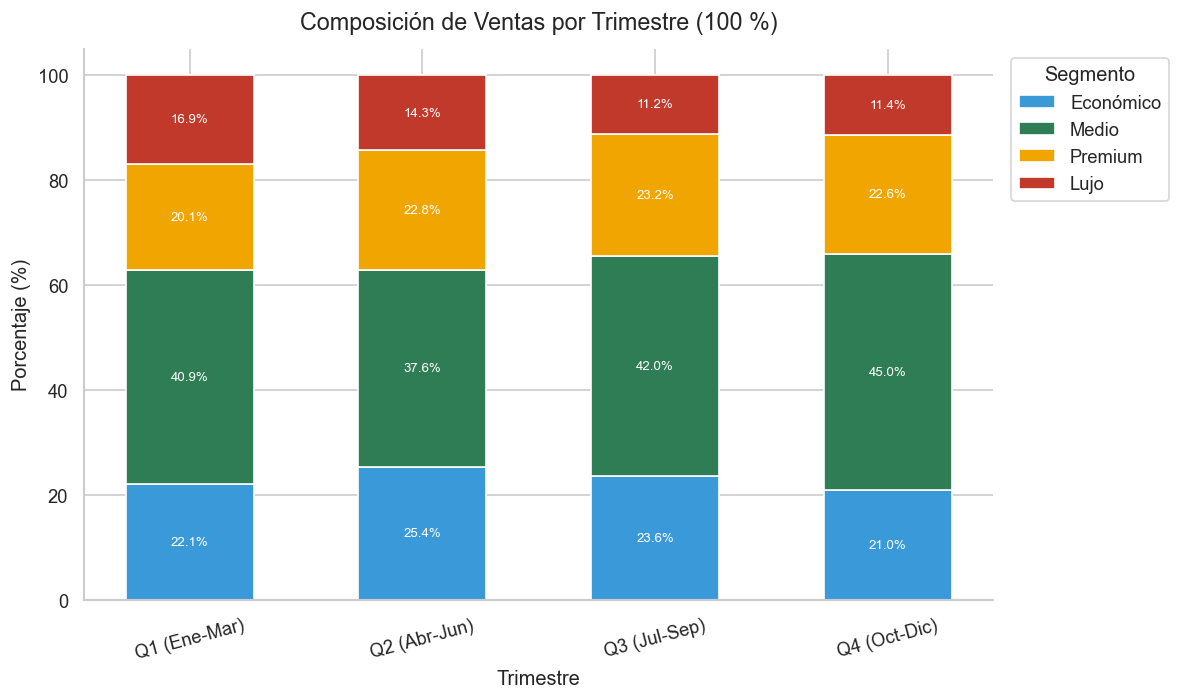

In [15]:
# Composición porcentual por trimestre
pivot_pct = pivot_trim.div(pivot_trim.sum(axis=1), axis=0) * 100 
 
fig, ax = plt.subplots(figsize=(10, 6)) 
bottom = np.zeros(len(pivot_pct)) 
 
for seg, color in zip(pivot_pct.columns, colores_seg2): 
    bars = ax.bar(pivot_pct.index, pivot_pct[seg], bottom=bottom, 
                  label=seg, color=color, edgecolor='white', width=0.55) 
    
    # Etiqueta dentro de la barra (solo si > 5 %) 
    for j, (b, h) in enumerate(zip(bottom, pivot_pct[seg])): 
        if h > 5: 
            ax.text(j, b + h / 2, f'{h:.1f}%', 
                    ha='center', va='center', fontsize=8, color='white'
                   )
            
    bottom += pivot_pct[seg].values 
            
ax.set_title('Composición de Ventas por Trimestre (100 %)', fontsize=14, pad=12) 
ax.set_xlabel('Trimestre') 
ax.set_ylabel('Porcentaje (%)') 
ax.set_ylim(0, 105) 
ax.tick_params(axis='x', rotation=15) 
ax.legend(title='Segmento', bbox_to_anchor=(1.01, 1), loc='upper left') 
ax.spines[['top', 'right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('graf_barras_apiladas100.png', dpi=150, bbox_inches='tight') 
plt.show() 

## 8. Dashboard consolidado

C:\Users\corre\AppData\Local\Temp\ipykernel_25272\831138914.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segmento', y='ventas',


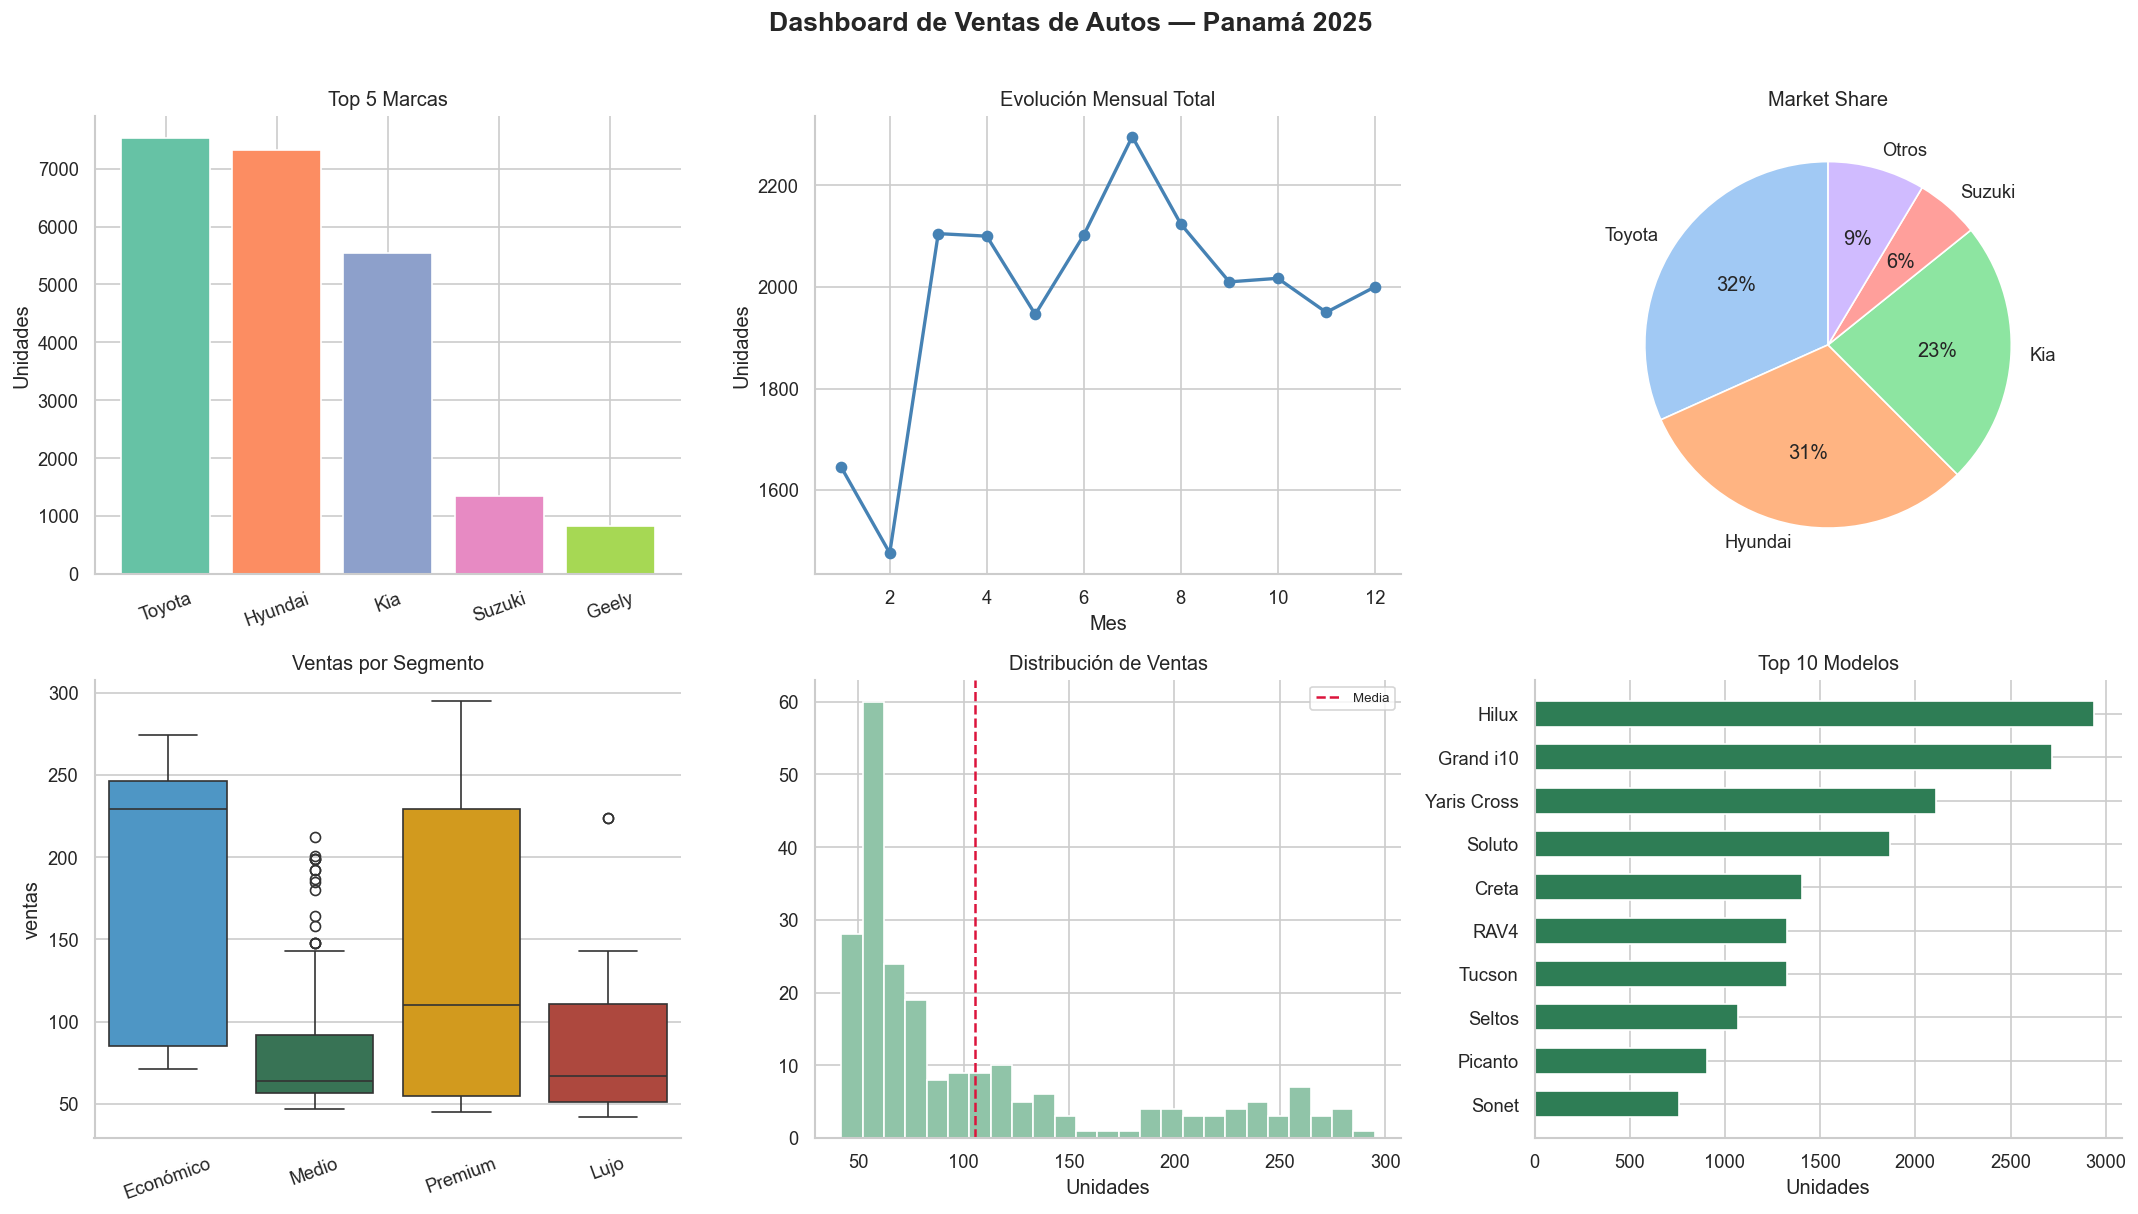

Dashboard guardado como dashboard_ventas_2025.png


In [16]:
# Dashboard — 6 paneles
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 
fig.suptitle('Dashboard de Ventas de Autos — Panamá 2025', 
             fontsize=16, fontweight='bold', y=1.01) 
 
# ── (0,0) Barras: Top 5 marcas ─────────────────────────────────── 
top5_vals = df.groupby('marca')['ventas'].sum().sort_values(ascending=False).head(5) 
axes[0,0].bar(top5_vals.index, 
              top5_vals.values,color=sns.color_palette('Set2', 5), edgecolor='white') 
axes[0,0].set_title('Top 5 Marcas') 
axes[0,0].set_ylabel('Unidades') 
axes[0,0].tick_params(axis='x', rotation=20) 
axes[0,0].spines[['top','right']].set_visible(False) 
 
# ── (0,1) Línea: evolución mensual total ───────────────────────── 
vm = df.groupby('mes')['ventas'].sum() 
axes[0,1].plot(vm.index, vm.values, marker='o', color='steelblue', linewidth=2) 
axes[0,1].set_title('Evolución Mensual Total') 
axes[0,1].set_xlabel('Mes') 
axes[0,1].set_ylabel('Unidades') 
axes[0,1].spines[['top','right']].set_visible(False) 
 
# ── (0,2) Pastel: market share ──────────────────────────────────── 
ms = df.groupby('marca')['ventas'].sum().sort_values(ascending=False) 
top4 = ms.head(4) 
top4['Otros'] = ms.iloc[4:].sum() 
axes[0,2].pie(top4.values, labels=top4.index, autopct='%1.0f%%', 
              startangle=90, colors=sns.color_palette('pastel'), 
              wedgeprops={'edgecolor':'white'}) 
axes[0,2].set_title('Market Share') 
 
# ── (1,0) Boxplot: ventas por segmento ──────────────────────────── 
sns.boxplot(data=df, x='segmento', y='ventas', 
            order=['Económico','Medio','Premium','Lujo'], 
            palette=['#3A9AD9','#2E7D55','#F0A500','#C0392B'], 
            linewidth=1, ax=axes[1,0]) 
axes[1,0].set_title('Ventas por Segmento') 
axes[1,0].set_xlabel('') 
axes[1,0].tick_params(axis='x', rotation=20) 
axes[1,0].spines[['top','right']].set_visible(False) 

# ── (1,1) Histograma: distribución de ventas ───────────────────── 
axes[1,1].hist(df['ventas'], bins=25, color='#90C4A8', edgecolor='white') 
axes[1,1].axvline(df['ventas'].mean(), color='crimson', linestyle='--', 
linewidth=1.5, label='Media') 
axes[1,1].set_title('Distribución de Ventas') 
axes[1,1].set_xlabel('Unidades') 
axes[1,1].legend(fontsize=8) 
axes[1,1].spines[['top','right']].set_visible(False) 


# ── (1,2) Barras horizontales: Top 10 modelos ──────────────────── 
top10_mod = (df.groupby('modelo')['ventas'].sum() 
.sort_values(ascending=True).tail(10)) 
axes[1,2].barh(top10_mod.index, top10_mod.values, 
color='#2E7D55', edgecolor='white', height=0.6) 
axes[1,2].set_title('Top 10 Modelos') 
axes[1,2].set_xlabel('Unidades') 
axes[1,2].spines[['top','right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('dashboard_ventas_2025.png', dpi=150, bbox_inches='tight') 
plt.show() 
print('Dashboard guardado como dashboard_ventas_2025.png') 


El dashboard junta todo lo anterior en una sola vista: Toyota, Hyundai y Kia arriba del resto, un pico de ventas a mitad de año, y Premium como el segmento más irregular. Los modelos top coinciden, como era de esperarse, con las marcas que ya lideraban el market share.